# Phase 3 (IHDS-II) — Baseline

[`walkthrough/ihds_phase3.md`](../walkthrough/ihds_phase3.md)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../dataset/ihds2_features.csv")

CATEGORICALS = ["Occupation", "Area_Type", "Caste_Group", "Religion"]
DROP = ["IDHH", "WT", "Goal_Met", "Savings_Rate"] + [c for c in df.columns if c.endswith("_CLR")]
NUMERIC = [c for c in df.columns if c not in DROP + CATEGORICALS]

X = df[NUMERIC + CATEGORICALS]
y = df["Goal_Met"]


def preprocessor(scaler=RobustScaler()):
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", scaler)]), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICALS),
    ])


print(f"households: {len(df):,}   numeric: {len(NUMERIC)}   categorical: {len(CATEGORICALS)}")
print(f"Goal_Met rate: {y.mean():.4f}")

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

CV = StratifiedKFold(5, shuffle=True, random_state=42)
SCORING = ["accuracy", "f1_macro", "roc_auc", "precision", "recall"]

households: 41,518   numeric: 24   categorical: 4
Goal_Met rate: 0.3193


## Q1 — What does a majority-class or simple single-rule baseline achieve?

In [2]:
def evaluate(model, cols, label):
    res = cross_validate(model, df[cols] if cols else X, y, cv=CV, scoring=SCORING)
    return {"model": label,
            "accuracy": res["test_accuracy"].mean(),
            "F1 (macro)": res["test_f1_macro"].mean(),
            "ROC-AUC": res["test_roc_auc"].mean(),
            "precision": res["test_precision"].mean(),
            "recall": res["test_recall"].mean()}


rows = [
    evaluate(DummyClassifier(strategy="most_frequent"), None, "Majority class (always 'not met')"),
    evaluate(DummyClassifier(strategy="stratified", random_state=42), None, "Stratified random"),
    evaluate(DummyClassifier(strategy="prior"), None, "Prior probability"),
]
baseline = pd.DataFrame(rows).set_index("model")
print(baseline.round(4).to_string())

                                   accuracy  F1 (macro)  ROC-AUC  precision  recall
model                                                                              
Majority class (always 'not met')    0.6807      0.4050   0.5000     0.0000  0.0000
Stratified random                    0.5649      0.4948   0.4949     0.3122  0.3013
Prior probability                    0.6807      0.4050   0.5000     0.0000  0.0000


In [3]:
# A single-rule baseline: split on income alone at the threshold that maximises macro-F1.
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier

stump = make_pipeline(SimpleImputer(strategy="median"),
                      DecisionTreeClassifier(max_depth=1, random_state=42))
rows = [evaluate(stump, ["Log_Income"], "Single rule: income only (depth-1 tree)")]

stump.fit(df[["Log_Income"]], y)
tree = stump.named_steps["decisiontreeclassifier"]
thr = tree.tree_.threshold[0]
print(f"learned rule: predict 'met' if Log_Income > {thr:.3f}  (= Rs {np.exp(thr):,.0f}/year)")
print(f"households above the threshold: {(df['Log_Income'] > thr).mean():.1%}\n")

rows.append(evaluate(make_pipeline(SimpleImputer(strategy="median"),
                                   DecisionTreeClassifier(max_depth=3, random_state=42)),
                     ["Log_Income"], "Income only (depth-3 tree)"))
print(pd.DataFrame(rows).set_index("model").round(4).to_string())

learned rule: predict 'met' if Log_Income > 11.709  (= Rs 121,685/year)
households above the threshold: 30.9%

                                         accuracy  F1 (macro)  ROC-AUC  precision  recall
model                                                                                    
Single rule: income only (depth-1 tree)    0.7753      0.7425   0.7438     0.6463  0.6566
Income only (depth-3 tree)                 0.7823      0.7281   0.8279     0.7169  0.5263


## Q2 — What does plain logistic regression achieve using only income and 1–2 expense shares?

In [4]:
MINIMAL_SETS = {
    "income only": ["Log_Income"],
    "income + groceries share": ["Log_Income", "Groceries_Share"],
    "income + groceries + insurance participation": ["Log_Income", "Groceries_Share", "Spends_On_Insurance"],
    "all 28 engineered features": None,
}

rows = []
for label, cols in MINIMAL_SETS.items():
    if cols is None:
        model = make_pipeline(preprocessor(), LogisticRegression(max_iter=2000, class_weight="balanced"))
        rows.append(evaluate(model, None, label))
    else:
        model = make_pipeline(SimpleImputer(strategy="median"), RobustScaler(),
                              LogisticRegression(max_iter=2000, class_weight="balanced"))
        rows.append(evaluate(model, cols, label))

progression = pd.DataFrame(rows).set_index("model")
print(progression.round(4).to_string())
print("\nmarginal ROC-AUC gain from each addition:")
print(progression["ROC-AUC"].diff().round(4).to_string())

                                              accuracy  F1 (macro)  ROC-AUC  precision  recall
model                                                                                         
income only                                     0.7528      0.7329   0.8348     0.5883  0.7519
income + groceries share                        0.7880      0.7705   0.8756     0.6326  0.8017
income + groceries + insurance participation    0.7902      0.7728   0.8771     0.6354  0.8048
all 28 engineered features                      0.8357      0.8202   0.9212     0.7001  0.8491

marginal ROC-AUC gain from each addition:
model
income only                                        NaN
income + groceries share                        0.0408
income + groceries + insurance participation    0.0015
all 28 engineered features                      0.0441


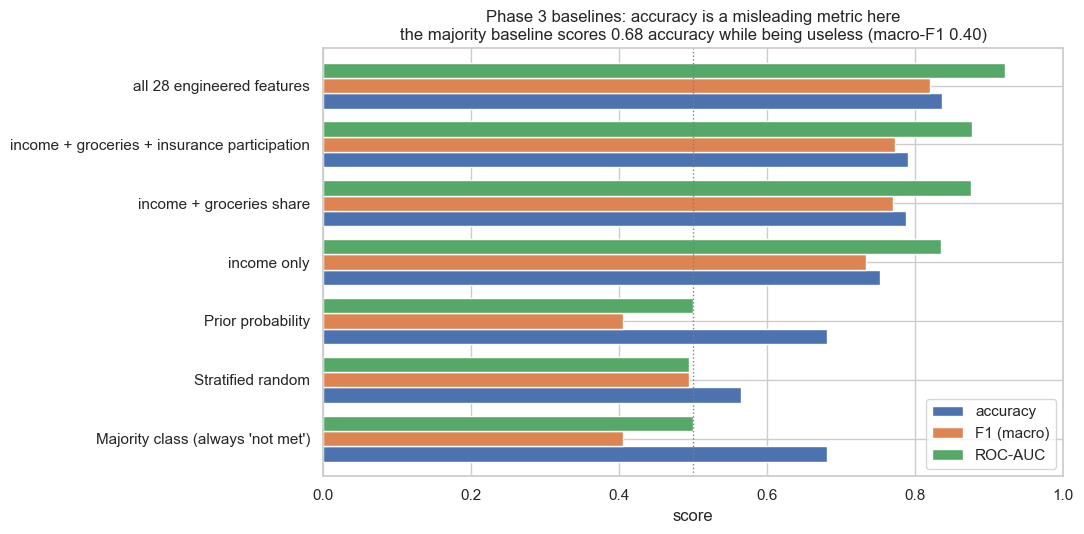

wrote ../results/ihds_baseline.csv and .png


In [5]:
full = pd.concat([baseline, progression])
full.to_csv("../results/ihds_baseline.csv")

fig, ax = plt.subplots(figsize=(11, 5.5))
plot = full[["accuracy", "F1 (macro)", "ROC-AUC"]]
plot.plot(kind="barh", ax=ax, width=0.78)
ax.axvline(0.5, color="grey", ls=":", lw=1)
ax.set_xlim(0, 1.0)
ax.set_xlabel("score")
ax.set_ylabel("")
ax.set_title("Phase 3 baselines: accuracy is a misleading metric here\n"
             "the majority baseline scores 0.68 accuracy while being useless (macro-F1 0.40)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/ihds_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print("wrote ../results/ihds_baseline.csv and .png")